<a href="https://www.kaggle.com/code/sawaira89khan/transfer-learning-vgg16?scriptVersionId=336694375" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Define MNIST class names (digits 0-9)
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Reshape data to include the single grayscale channel dimension (28, 28, 1)
x_train_expanded = np.expand_dims(x_train, axis=-1)
x_test_expanded = np.expand_dims(x_test, axis=-1)

# One-hot encode targets for categorical crossentropy
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# Display metadata
print(f"x_train shape: {x_train_expanded.shape} | y_train shape: {y_train_cat.shape}")
print(f"x_test shape: {x_test_expanded.shape} | y_test shape: {y_test_cat.shape}")
print(f"Dataset unique classes: {len(class_names)} ({class_names})")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1) | y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1) | y_test shape: (10000, 10)
Dataset unique classes: 10 (['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])


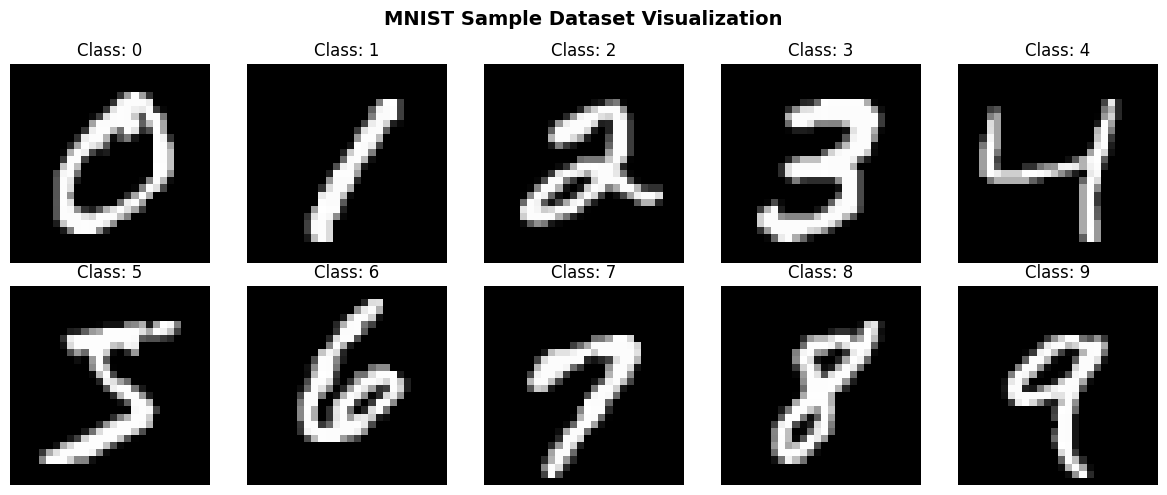

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Grab the first image index belonging to class 'i'
    idx = np.where(y_train == i)[0][0]
    
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"Class: {class_names[i]}")
    plt.axis('off')

plt.suptitle("MNIST Sample Dataset Visualization", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Build a clean sequential data augmentation block
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

I0000 00:00:1784551342.485369      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
# Build a clean sequential data augmentation block
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

In [6]:
# Define model input layer matching our expanded shape
inputs = layers.Input(shape=(28, 28, 1))

# Apply augmentation sequential block
x = data_augmentation(inputs)

# Resize to minimum VGG16 compatible dimension (32x32)
x = layers.Resizing(32, 32)(x)

# Transform single-channel grayscale to 3-channel RGB
x = layers.Lambda(lambda images: tf.image.grayscale_to_rgb(images))(x)

# Pass through official VGG16 preprocessing wrapper
x = tf.keras.applications.vgg16.preprocess_input(x)

# Load VGG16 backbone with ImageNet weights, omitting final top layers
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# PHASE 1 FREEZE: Freeze all layers in the VGG base model
vgg_base.trainable = False

# Route features through backbone
x = vgg_base(x, training=False)

# Custom dense classification head
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

# Build final graph
model = models.Model(inputs, outputs)

# Compile step for Phase 1
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display full network parameter breakdown
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 28, 28, 1) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 32, 32, 1) │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32, 32, 3) │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 32, 32)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 32, 32)    │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 32, 32)    │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 32, 32, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 1, 1, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 512)       │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=2, 
    restore_best_weights=True
)

history_phase1 = model.fit(
    x_train_expanded, y_train_cat,
    epochs=10, # Set higher, but early stopping prevents wasted time
    validation_data=(x_test_expanded, y_test_cat),
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7854 - loss: 0.9513 - val_accuracy: 0.8993 - val_loss: 0.2948
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8751 - loss: 0.3935 - val_accuracy: 0.9144 - val_loss: 0.2612
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8903 - loss: 0.3418 - val_accuracy: 0.9132 - val_loss: 0.2576
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8971 - loss: 0.3230 - val_accuracy: 0.9191 - val_loss: 0.2295
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9014 - loss: 0.3063 - val_accuracy: 0.9282 - val_loss: 0.2159
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9056 - loss: 0.2914 - val_accuracy: 0.9330 - val_loss: 0.2006
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9074 - loss: 0.2879 - val_accuracy: 0.9307 - val_loss: 0.2026
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9093 - loss: 0.2780 - 

In [8]:
print("\n=== Inspecting and Freezing VGG16 Layers ===")

# 1. Unfreeze the base model entirely first
vgg_base.trainable = True

# 2. Loop through every layer in the VGG16 base
for layer in vgg_base.layers:
    # If the layer name starts with 'block5_', keep it trainable
    if layer.name.startswith('block5_'):
        layer.trainable = True
    else:
        # Otherwise, freeze the earlier feature extraction layers (Blocks 1-4)
        layer.trainable = False

# 3. Print the status of each layer for your teacher's inspection requirement
print(f"{'Layer Index':<12} | {'Layer Name':<22} | {'Trainable Status'}")
print("-" * 55)
for i, layer in enumerate(vgg_base.layers):
    print(f"Layer {i:02d}       | {layer.name:<22} | {layer.trainable}")

# 4. Recompile with a very low learning rate (1e-5) to prevent destroying pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== Updated Parameter Breakdown for Fine-Tuning ===")
model.summary()

# 5. Optional: Add early stopping here too to optimize training before your deadline
early_stop_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("\n=== Executing Phase 2: Fine-Tuning Block 5 + Head ===")
history_phase2 = model.fit(
    x_train_expanded, y_train_cat,
    epochs=5, # Allowed up to 5 epochs, but early stopping will halt if it converges early
    validation_data=(x_test_expanded, y_test_cat),
    batch_size=64,
    callbacks=[early_stop_phase2]
)


=== Inspecting and Freezing VGG16 Layers ===
Layer Index  | Layer Name             | Trainable Status
-------------------------------------------------------
Layer 00       | input_layer_2          | False
Layer 01       | block1_conv1           | False
Layer 02       | block1_conv2           | False
Layer 03       | block1_pool            | False
Layer 04       | block2_conv1           | False
Layer 05       | block2_conv2           | False
Layer 06       | block2_pool            | False
Layer 07       | block3_conv1           | False
Layer 08       | block3_conv2           | False
Layer 09       | block3_conv3           | False
Layer 10       | block3_pool            | False
Layer 11       | block4_conv1           | False
Layer 12       | block4_conv2           | False
Layer 13       | block4_conv3           | False
Layer 14       | block4_pool            | False
Layer 15       | block5_conv1           | True
Layer 16       | block5_conv2           | True
Layer 17       | block5_con

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 28, 28, 1) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 32, 32, 1) │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32, 32, 3) │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 32, 32)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 32, 32)    │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 32, 32)    │          0 │ lambda[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 32, 32, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 1, 1, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 512)       │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)


=== Executing Phase 2: Fine-Tuning Block 5 + Head ===
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9486 - loss: 0.1735 - val_accuracy: 0.9728 - val_loss: 0.0959
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9660 - loss: 0.1154 - val_accuracy: 0.9731 - val_loss: 0.1014
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9734 - loss: 0.0932 - val_accuracy: 0.9791 - val_loss: 0.0733
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9782 - loss: 0.0766 - val_accuracy: 0.9813 - val_loss: 0.0689
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9792 - loss: 0.0703 - val_accuracy: 0.9808 - val_loss: 0.0789


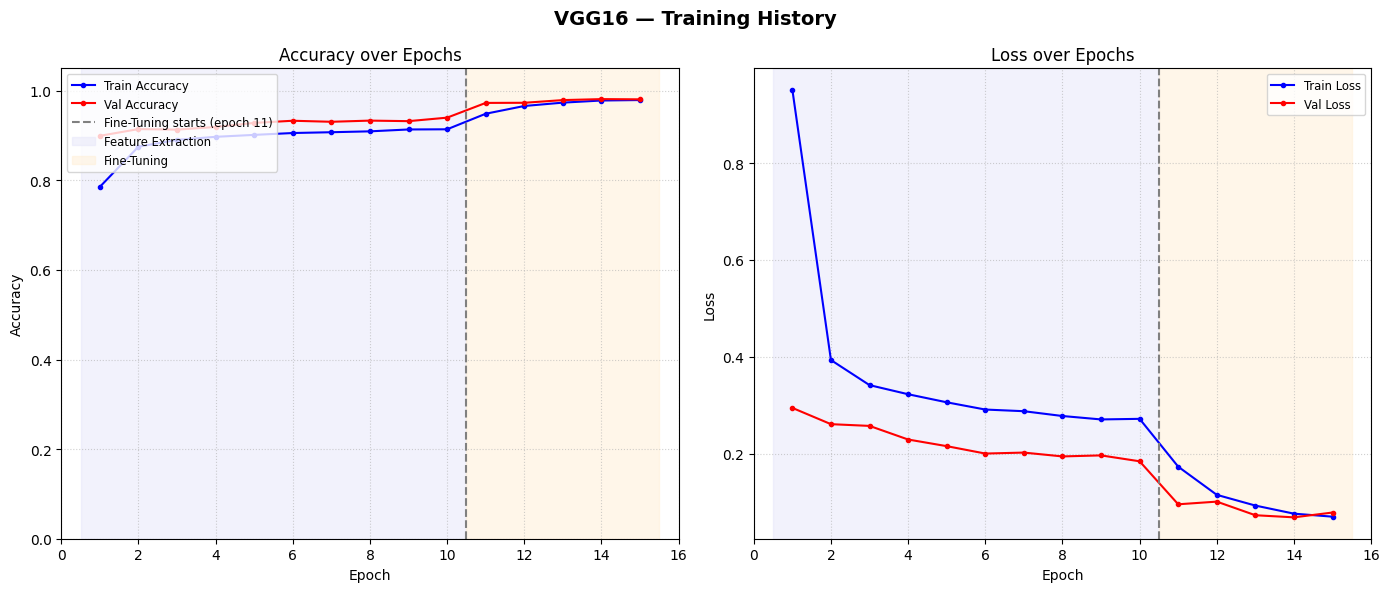


Final Results:
  Best Val Accuracy (Phase 1): 0.9399
  Best Val Accuracy (Phase 2): 0.9813


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Combine Histories ---
# Extract metrics from Phase 1
p1_loss = history_phase1.history['loss']
p1_acc = history_phase1.history['accuracy']
p1_val_loss = history_phase1.history['val_loss']
p1_val_acc = history_phase1.history['val_accuracy']

# Extract metrics from Phase 2
p2_loss = history_phase2.history['loss']
p2_acc = history_phase2.history['accuracy']
p2_val_loss = history_phase2.history['val_loss']
p2_val_acc = history_phase2.history['val_accuracy']

# Concatenate them to create a continuous line plot
total_loss = p1_loss + p2_loss
total_acc = p1_acc + p2_acc
total_val_loss = p1_val_loss + p2_val_loss
total_val_acc = p1_val_acc + p2_val_acc

# Generate total epoch sequence (starting from 1)
epochs = np.arange(1, len(total_loss) + 1)
split_epoch = len(p1_loss)  # The exact boundary line

# --- 2. Setup Plot Canvas ---
plt.figure(figsize=(14, 6))
plt.suptitle("VGG16 — Training History", fontsize=14, fontweight='bold')

# --- LEFT PLOT: Accuracy over Epochs ---
plt.subplot(1, 2, 1)
plt.plot(epochs, total_acc, 'b.-', label='Train Accuracy')
plt.plot(epochs, total_val_acc, 'r.-', label='Val Accuracy')
plt.axvline(x=split_epoch + 0.5, color='gray', linestyle='--', label=f'Fine-Tuning starts (epoch {split_epoch + 1})')

# Color background sections
plt.axvspan(0.5, split_epoch + 0.5, color='lavender', alpha=0.5, label='Feature Extraction')
plt.axvspan(split_epoch + 0.5, len(total_loss) + 0.5, color='papayawhip', alpha=0.5, label='Fine-Tuning')

plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(0, len(total_loss) + 1)
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize='small', loc='upper left')

# --- RIGHT PLOT: Loss over Epochs ---
plt.subplot(1, 2, 2)
plt.plot(epochs, total_loss, 'b.-', label='Train Loss')
plt.plot(epochs, total_val_loss, 'r.-', label='Val Loss')
plt.axvline(x=split_epoch + 0.5, color='gray', linestyle='--')

# Color background sections
plt.axvspan(0.5, split_epoch + 0.5, color='lavender', alpha=0.5)
plt.axvspan(split_epoch + 0.5, len(total_loss) + 0.5, color='papayawhip', alpha=0.5)

plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xlim(0, len(total_loss) + 1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()

# --- 3. Print the Final Formatted Text Summary ---
print("\nFinal Results:")
print(f"  Best Val Accuracy (Phase 1): {max(p1_val_acc):.4f}")
print(f"  Best Val Accuracy (Phase 2): {max(total_val_acc):.4f}")

In [10]:
# — Final Evaluation —
test_loss, test_acc = model.evaluate(x_test_expanded, y_test_cat, verbose=0)

print(f"\n{'='*45}")
print(f"  VGG16 Transfer Learning – Test Results")
print(f"{'='*45}")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test Loss     : {test_loss:.4f}")


  VGG16 Transfer Learning – Test Results
  Test Accuracy : 0.9813 (98.13%)
  Test Loss     : 0.0689


In [11]:
# — Predictions —

# Get predictions on the entire test set
y_pred_prob = model.predict(x_test_expanded, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)  # predicted class indices
y_true      = y_test.flatten()                 # true class indices


# — Classification Report —
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       1.00      0.95      0.97       892
           6       0.99      0.99      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.94      0.99      0.96       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



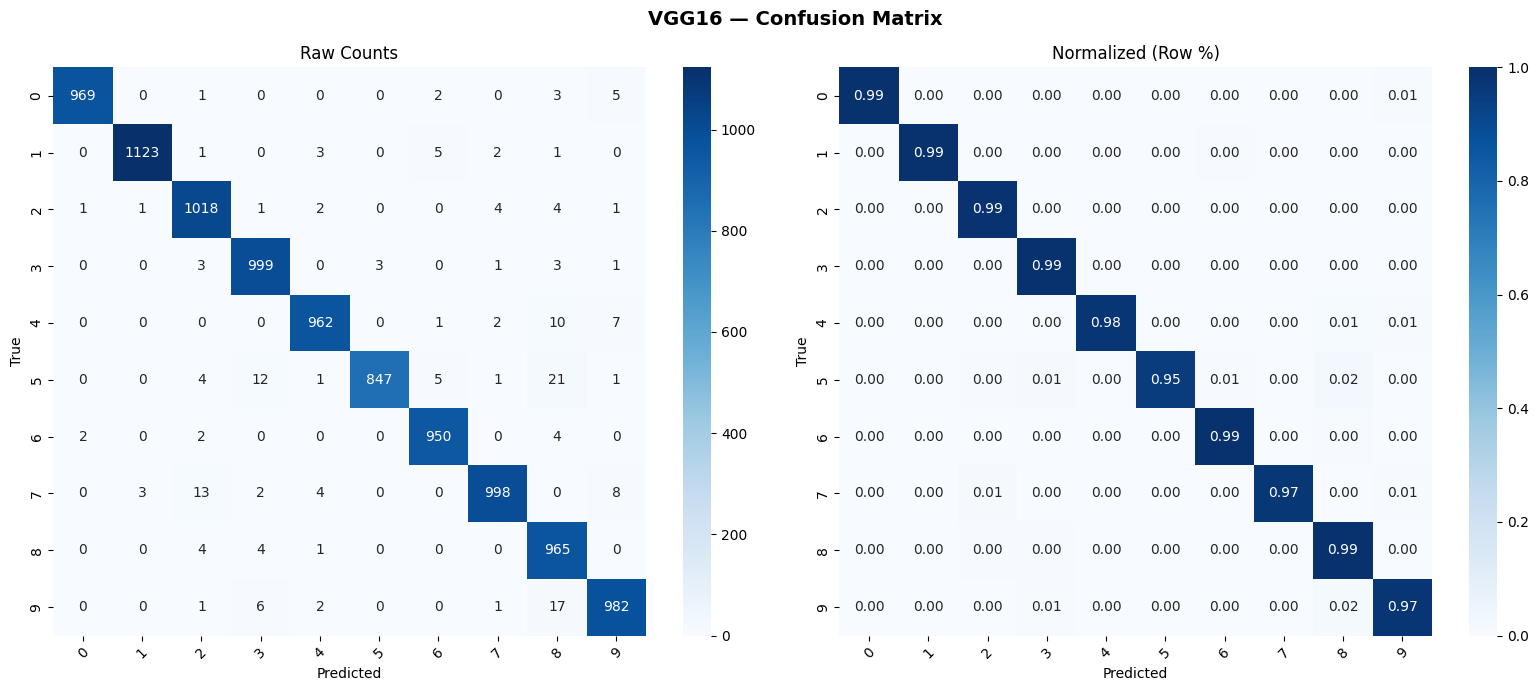

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- 1. Compute Confusion Matrices ---
# Raw confusion matrix counts
cm_raw = confusion_matrix(y_true, y_pred)

# Normalized confusion matrix (divide each row by its sum)
cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]

# --- 2. Setup Plot Canvas ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("VGG16 — Confusion Matrix", fontsize=14, fontweight='bold')

# --- LEFT PLOT: Raw Counts ---
sns.heatmap(
    cm_raw, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names, 
    ax=axes[0],
    cbar=True
)
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticklabels(class_names, rotation=45)

# --- RIGHT PLOT: Normalized (Row %) ---
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names, 
    ax=axes[1],
    cbar=True,
    vmin=0.0,
    vmax=1.0
)
axes[1].set_title("Normalized (Row %)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

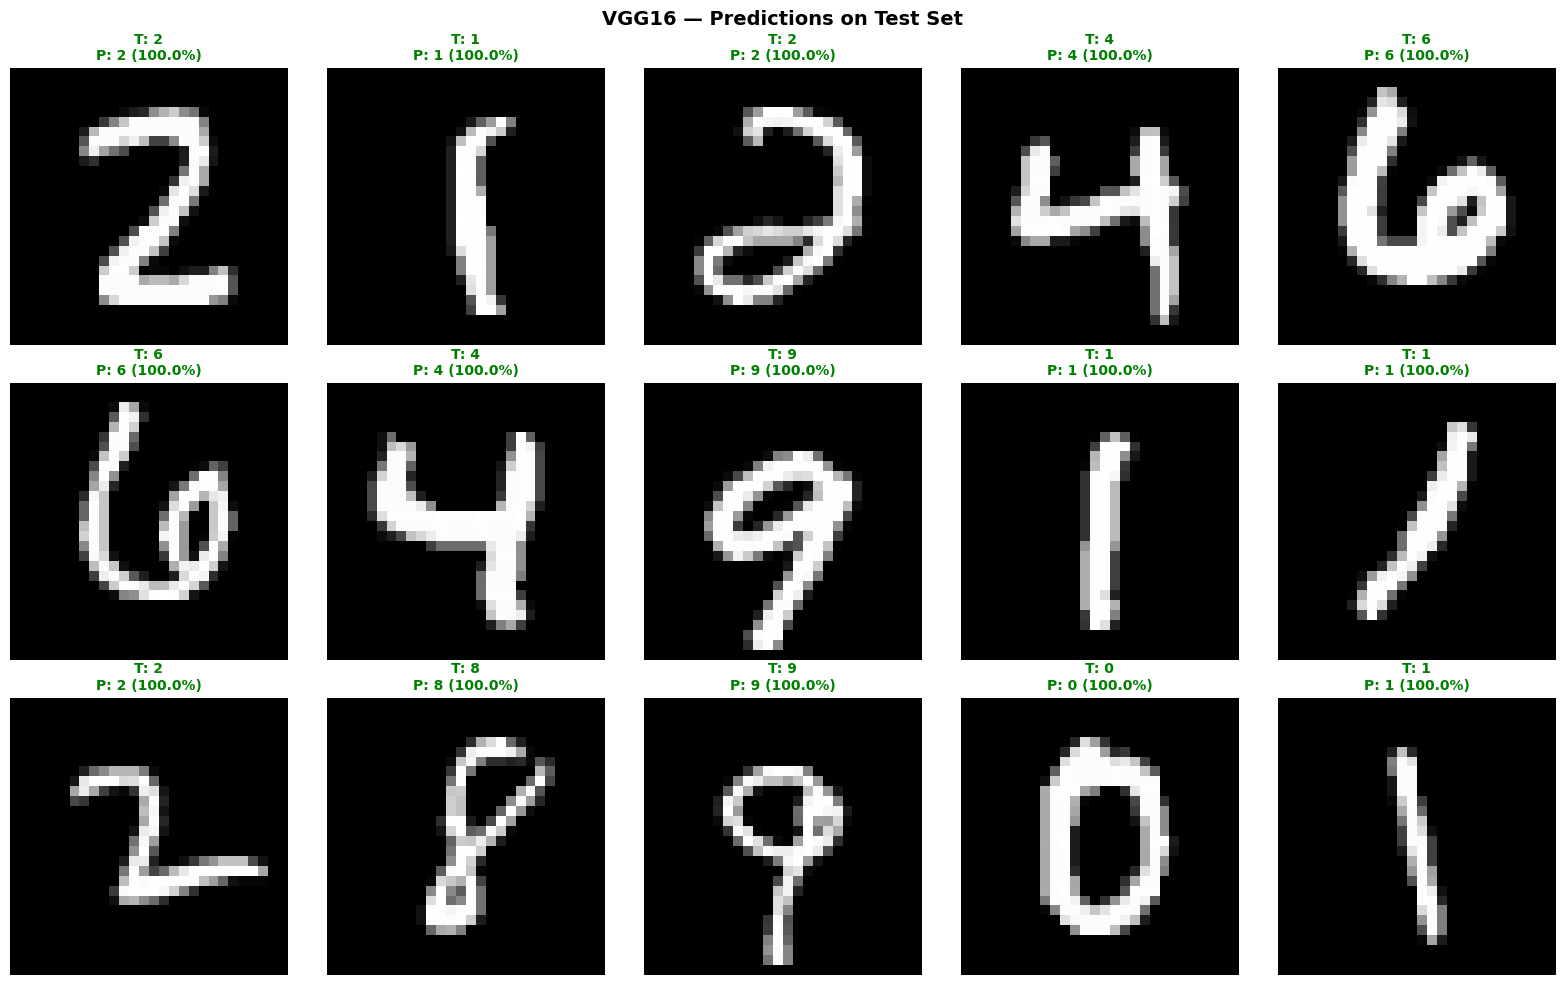

In [13]:
import random

# --- 1. Select a Random Sample of Test Images ---
# We'll take 15 random sample indices to create a 3x5 grid matching your reference
random.seed(42)  # Optional: sets a seed so your results stay consistent each run
sample_indices = random.sample(range(len(x_test)), 15)

# --- 2. Setup Plot Canvas ---
plt.figure(figsize=(16, 10))
plt.suptitle("VGG16 — Predictions on Test Set", fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_indices):
    plt.subplot(3, 5, i + 1)
    
    # Show the original grayscale image
    plt.imshow(x_test[idx], cmap='gray')
    plt.axis('off')
    
    # Get true label and predicted probabilities
    true_label_idx = y_true[idx]
    pred_prob_distribution = y_pred_prob[idx]
    
    # Find the predicted class and its specific confidence percentage
    predicted_label_idx = np.argmax(pred_prob_distribution)
    confidence = pred_prob_distribution[predicted_label_idx] * 100
    
    true_name = class_names[true_label_idx]
    pred_name = class_names[predicted_label_idx]
    
    title_text = f"T: {true_name}\nP: {pred_name} ({confidence:.1f}%)"
    
    # Color code text: green if correct, red if incorrect
    if true_label_idx == predicted_label_idx:
        color = 'green'
    else:
        color = 'red'
        
    plt.title(title_text, fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

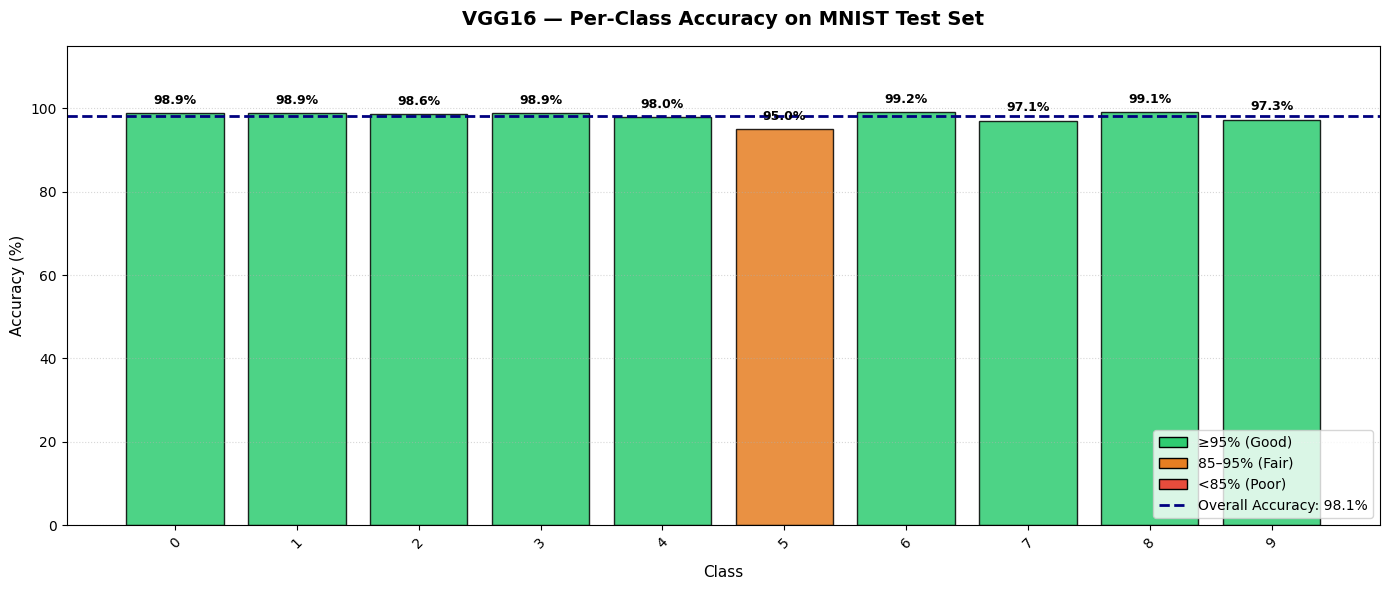


Per-class accuracy:
  6            : ███████████████████████████████████████  99.2%
  8            : ███████████████████████████████████████  99.1%
  1            : ███████████████████████████████████████  98.9%
  3            : ███████████████████████████████████████  98.9%
  0            : ███████████████████████████████████████  98.9%
  2            : ███████████████████████████████████████  98.6%
  4            : ███████████████████████████████████████  98.0%
  9            : ██████████████████████████████████████   97.3%
  7            : ██████████████████████████████████████   97.1%
  5            : █████████████████████████████████████    95.0%


In [14]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

class_accuracies = cm.diagonal() / cm.sum(axis=1)
per_class_acc_dict = dict(zip(class_names, class_accuracies))

# --- 2. Color Categorization Logic ---
colors = []
for acc in class_accuracies:
    if acc >= 0.95:
        colors.append('#2ecc71')  # Green (Good)
    elif acc >= 0.85:
        colors.append('#e67e22')  # Orange (Fair)
    else:
        colors.append('#e74c3c')  # Red (Poor)

# --- 3. Setup Plot Canvas ---
plt.figure(figsize=(14, 6))
bars = plt.bar(class_names, class_accuracies * 100, color=colors, edgecolor='black', alpha=0.85)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height + 1.5,
        f'{height:.1f}%',
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=9
    )

# Draw overall accuracy baseline (test_acc comes from Step 8)
overall_acc_pct = test_acc * 100
plt.axhline(y=overall_acc_pct, color='navy', linestyle='--', linewidth=2, 
            label=f'Overall Accuracy: {overall_acc_pct:.1f}%')

# Formatting labels and axes
plt.title("VGG16 — Per-Class Accuracy on MNIST Test Set", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Class", fontsize=11, labelpad=10)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.ylim(0, 115)  # Give headroom for labels
plt.grid(axis='y', linestyle=':', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='≥95% (Good)'),
    Patch(facecolor='#e67e22', edgecolor='black', label='85–95% (Fair)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='<85% (Poor)'),
    plt.Line2D([0], [0], color='navy', linestyle='--', linewidth=2, label=f'Overall Accuracy: {overall_acc_pct:.1f}%')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
sorted_classes = sorted(per_class_acc_dict.items(), key=lambda item: item[1], reverse=True)

for name, acc_val in sorted_classes:
    pct_val = acc_val * 100
    bar_visualization = "█" * int(pct_val // 2.5)
    print(f"  {name:<12} : {bar_visualization:<40} {pct_val:.1f}%")